# VOC2012 Val — SAM3 base **vs** Improved SAM3 (per-class IoU, 1449 ảnh)

Đo trên **toàn bộ 1449 ảnh val**, query đủ 20 class → mIoU chuẩn VOC (có phạt false-positive trên ảnh negative).

## Pipeline hai cột

| Cột | 4 target (`bicycle/chair/diningtable/sofa`) | `pottedplant` | 15 class còn lại |
|---|---|---|---|
| **BASE** | SAM3 base | SAM3 base | SAM3 base |
| **FT** | SAM3 **fine-tuned (LoRA)** | **Dual-prompt** @ 0.3 | **= BASE** (ΔIoU = 0, đảm bảo bằng construction) |

## Cách build `pred_ft` (đảm bảo 15 class không đổi)

1. Copy `pred_base` → `pred_ft`.
2. **Clear** pixel của 5 weak class (4 target + pottedplant) → set 0.
3. Score-argmax **SAM3 FT** (4 target) vào pixel đang = 0.
4. **Plant dual-prompt** (`'potted plant with its pot or container'` + `'flowerpot'` union @ 0.3, dùng SAM3 base) vào pixel còn = 0.

→ Pixel của 15 class không-weak không bao giờ bị chạm → FT col = BASE col cho 15 class đó.

## BASE inference — khớp chính xác `test-all-unetaspp-dino.ipynb`

- Load base model **trước khi** apply PE patch → base dùng original `PositionEmbeddingSine`.
- Trong `run_base_all_and_plant`: **restore** original `addmm_act` → base chạy không có patch.
- Autocast **bfloat16** (giống global bf16 của test-all).
- Prompt = **raw class name** (`'diningtable'`, `'pottedplant'`, …) — khớp `BASELINE_PROMPTS`.
- Plant dual-prompt trong cùng session (reuse state), threshold 0.3.
- `finally` block **re-apply** FT patches sau mỗi lần base chạy → FT inference luôn đúng.

## FT inference — khớp môi trường train v16

- Load FT model **sau khi** apply PE patch → FT dùng `precompute_resolution=800`.
- `addmm_act` patch active trong FT inference (guaranteed by finally block của base).
- `model.float().eval()` + per-call `autocast(float32)`.
- Load adapter bằng `PeftModel.from_pretrained`.
- conf = 0.3, no TTA.

> Bỏ patch (addmm_act / PE) cho FT hoặc chạy bf16 → LoRA delta sai → mask rác.

In [1]:
!pip install --no-deps git+https://github.com/facebookresearch/sam3.git -q
!pip install timm ftfy iopath portalocker peft albumentations safetensors -q

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 1.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 98.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sam3 0.1.0 requires ftfy==6.1.1, but you have ftfy 6.3.1 which is incompatible.
sam3 0.1.0 requires numpy<2,>=1.26, but you have numpy 2.4.6 which is incompatible.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-

In [2]:
# Imports + SAM3 patches (chi ap dung cho FT model; base se dung original functions)
import os
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

import gc, time, traceback
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from tqdm.auto import tqdm
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms.functional as TF

import sam3
from sam3 import build_sam3_image_model
from sam3.model.sam3_image_processor import Sam3Processor
from peft import PeftModel

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# ── Luu originals TRUOC khi patch (de base model chay nhu test-all-unetaspp-dino) ──
import sam3.model.position_encoding as _pe
import sam3.perflib.fused as _fused_mod
import sam3.model.vitdet as _vitdet_mod

_orig_PE           = _pe.PositionEmbeddingSine       # cho load base model
_orig_fused_addmm  = _fused_mod.addmm_act            # cho base inference
_orig_vitdet_addmm = _vitdet_mod.addmm_act           # cho base inference

# ── Patch 1: PositionEmbeddingSine precompute_resolution=800 (chi cho FT model) ──
class _PatchedPE(_orig_PE):
    def __init__(self, *args, **kwargs):
        kwargs['precompute_resolution'] = 800
        super().__init__(*args, **kwargs)
_pe.PositionEmbeddingSine = _PatchedPE

# ── Patch 2: addmm_act -> F.linear + activation (chi cho FT model) ──
def _patched_addmm_act(activation, linear, mat1):
    out  = F.linear(mat1, linear.weight, linear.bias)
    name = getattr(activation, "__name__", str(activation)).lower()
    if "gelu" in name: return F.gelu(out)
    if "relu" in name: return F.relu(out)
    if "silu" in name or "swish" in name: return F.silu(out)
    try:    return activation()(out)
    except: return F.gelu(out)
_fused_mod.addmm_act  = _patched_addmm_act
_vitdet_mod.addmm_act = _patched_addmm_act

def _restore_base_patches():
    """Khoi phuc original addmm_act -> base runs giong test-all (no patch)."""
    _fused_mod.addmm_act  = _orig_fused_addmm
    _vitdet_mod.addmm_act = _orig_vitdet_addmm

def _apply_ft_patches():
    """Re-apply FT patches sau khi base inference xong."""
    _fused_mod.addmm_act  = _patched_addmm_act
    _vitdet_mod.addmm_act = _patched_addmm_act

print(f'PyTorch {torch.__version__} | CUDA {torch.cuda.is_available()} | {DEVICE}')
print('Originals saved. FT patches applied (PE=800, addmm_act).')
print('Base inference will: _restore_base_patches() + bfloat16 (same env as test-all)')
print('FT  inference will: _apply_ft_patches()    + float32  (v16 env)')

/usr/local/lib/python3.12/dist-packages/sam3/model/model_misc.py:70: UserWarning: Flash Attention is disabled as it requires a GPU with Ampere (8.0) CUDA capability.
  OLD_GPU, USE_FLASH_ATTN, MATH_KERNEL_ON = get_sdpa_settings()
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


PyTorch 2.10.0+cu128 | CUDA True | cuda
Originals saved. FT patches applied (PE=800, addmm_act).
Base inference will: _restore_base_patches() + bfloat16 (same env as test-all)
FT  inference will: _apply_ft_patches()    + float32  (v16 env)


In [3]:
# Paths (nhieu candidate -> tu dong chon cai ton tai tren Kaggle)
def _first_exist(cands, label):
    for c in cands:
        if Path(c).exists():
            return Path(c)
    raise FileNotFoundError(f"{label} khong tim thay. Da thu: {cands}")

VOC_ROOT = _first_exist([
    '/kaggle/input/datasets/dngomnh/pascalvoc/VOCdevkit/VOC2012',
    '/kaggle/input/datasets/tunmaixun/voc2012/VOCdevkit/VOC2012',
    '/kaggle/input/pascalvoc/VOCdevkit/VOC2012',
    './VOC2012',
], 'VOC_ROOT')

SAM3_CKPT = _first_exist([
    '/kaggle/input/datasets/dngomnh/modelsam3/sam3.pt',
    '/kaggle/input/models/tunmaixun/sam3/other/default/1/sam3.pt',
    '/kaggle/input/sam3/sam3.pt',
    './sam3.pt',
], 'SAM3_CKPT')

# Thu muc adapter LoRA da fine-tune (chua adapter_config.json + adapter_model.safetensors)
FT_ADAPTER_DIR = _first_exist([
    '/kaggle/input/sam3-voc-lora/model_finetune',
    '/kaggle/input/datasets/trungkienksd/sam3-finetune/model_finetune',
    '/kaggle/input/model-finetune',
    './model_finetune',
], 'FT_ADAPTER_DIR')

JPEG_DIR = VOC_ROOT / 'JPEGImages'
MASK_DIR = VOC_ROOT / 'SegmentationClass'
VAL_FILE = VOC_ROOT / 'ImageSets' / 'Segmentation' / 'val.txt'

_sam3_dir = Path(sam3.__file__).parent
BPE_PATH  = _sam3_dir / 'assets' / 'bpe_simple_vocab_16e6.txt.gz'

# ── VOC 20 classes ──
VOC_CLASSES = [
    'aeroplane','bicycle','bird','boat','bottle','bus','car','cat',
    'chair','cow','diningtable','dog','horse','motorbike','person',
    'pottedplant','sheep','sofa','train','tvmonitor',
]
VOC_IDX = {n: i+1 for i, n in enumerate(VOC_CLASSES)}   # 1..20
NUM_VOC = 21                                              # 0=bg, 1..20, 255=ignore

# ── 4 target class -> FT model ──
TARGET_CLASSES    = ['bicycle', 'chair', 'diningtable', 'sofa']
BASE_ONLY_CLASSES = [c for c in VOC_CLASSES if c not in TARGET_CLASSES]   # 16 class

# Prompt cho SAM3 BASE: raw class name, giong BASELINE_PROMPTS trong test-all-unetaspp-dino
BASE_PROMPTS = {name: name for name in VOC_CLASSES}

# Prompt cho SAM3 FT (4 target): co the dung prompt mo ta hon de FT inference tot hon
PROMPTS = {c: c for c in VOC_CLASSES}
PROMPTS.update({
    'bicycle':     'bicycle',
    'chair':       'chair',
    'diningtable': 'dining table',
    'sofa':        'sofa',
})

# Plant dual-prompt (giong Pass 4 trong test-all-unetaspp-dino)
PLANT_PROMPTS    = ['potted plant with its pot or container', 'flowerpot']
PLANT_CONFIDENCE = 0.3
PLANT_VOC_IDX    = VOC_IDX['pottedplant']

# 5 weak class IDs (4 target + pottedplant): se bi clear trong pred_ft truoc khi assign lai
TARGET_WEAK_IDS = np.array(
    [VOC_IDX[c] for c in TARGET_CLASSES + ['pottedplant']], dtype=np.uint8
)

EVAL_CONF = 0.3
USE_TTA   = False   # khop eval v16

with open(VAL_FILE) as f:
    val_ids = [l.strip() for l in f if l.strip()]

print(f'VOC_ROOT          : {VOC_ROOT}')
print(f'SAM3_CKPT         : {SAM3_CKPT}')
print(f'FT_ADAPTER_DIR    : {FT_ADAPTER_DIR}')
print(f'Val images        : {len(val_ids)}')
print(f'FT (4 target)     : {TARGET_CLASSES}')
print(f'BASE_ONLY (16)    : {BASE_ONLY_CLASSES}')
print(f'conf={EVAL_CONF} | TTA={USE_TTA}')
print(f'Plant dual-prompt : {PLANT_PROMPTS} @ thr={PLANT_CONFIDENCE}')
print(f'TARGET_WEAK_IDS   : {TARGET_WEAK_IDS}')

VOC_ROOT          : /kaggle/input/datasets/dngomnh/pascalvoc/VOCdevkit/VOC2012
SAM3_CKPT         : /kaggle/input/datasets/dngomnh/modelsam3/sam3.pt
FT_ADAPTER_DIR    : /kaggle/input/datasets/trungkienksd/sam3-finetune/model_finetune
Val images        : 1449
FT (4 target)     : ['bicycle', 'chair', 'diningtable', 'sofa']
BASE_ONLY (16)    : ['aeroplane', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'cow', 'dog', 'horse', 'motorbike', 'person', 'pottedplant', 'sheep', 'train', 'tvmonitor']
conf=0.3 | TTA=False
Plant dual-prompt : ['potted plant with its pot or container', 'flowerpot'] @ thr=0.3
TARGET_WEAK_IDS   : [ 2  9 11 18 16]


In [4]:
# Load models: base (original PE, no patch) -> apply PE patch -> FT (patched PE + LoRA)
gc.collect(); torch.cuda.empty_cache()

# ── Load SAM3 base: temporarily restore original PE so base model has NO precompute=800 ──
print('Loading SAM3 base (original PE, original addmm_act)...')
_pe.PositionEmbeddingSine = _orig_PE   # restore original PE for base build
_restore_base_patches()                # restore original addmm_act during build

model_base = build_sam3_image_model(
    bpe_path=str(BPE_PATH), checkpoint_path=str(SAM3_CKPT), load_from_HF=False,
).float().eval().to(DEVICE)
proc_base = Sam3Processor(model_base, confidence_threshold=EVAL_CONF)
print(f'  base dtype : {next(model_base.parameters()).dtype}  |  PE: original')

# ── Re-apply ALL FT patches before building FT model ──
_pe.PositionEmbeddingSine = _PatchedPE
_apply_ft_patches()

# ── Load SAM3 FT: built WITH patched PE (precompute=800) + patched addmm_act ──
print('Loading SAM3 base for FT then attaching LoRA adapter...')
_model_ft_base = build_sam3_image_model(
    bpe_path=str(BPE_PATH), checkpoint_path=str(SAM3_CKPT), load_from_HF=False,
).to(DEVICE)
for p in _model_ft_base.parameters():
    p.requires_grad = False

model_ft = PeftModel.from_pretrained(_model_ft_base, str(FT_ADAPTER_DIR))
model_ft = model_ft.float().eval()
proc_ft  = Sam3Processor(model_ft, confidence_threshold=EVAL_CONF)

n_lora = sum(1 for n, _ in model_ft.named_parameters() if 'lora_' in n.lower())
print(f'  FT dtype   : {next(model_ft.parameters()).dtype}  |  PE: patched (precompute=800)')
print(f'  LoRA params: {n_lora} tensors')
print(f'VRAM alloc: {torch.cuda.memory_allocated()/1e9:.2f}GB | '
      f'free: {torch.cuda.mem_get_info()[0]/1e9:.2f}GB')

Loading SAM3 base (original PE, original addmm_act)...
  base dtype : torch.float32  |  PE: original
Loading SAM3 base for FT then attaching LoRA adapter...
  FT dtype   : torch.float32  |  PE: patched (precompute=800)
  LoRA params: 296 tensors
VRAM alloc: 7.15GB | free: 8.33GB


In [5]:
# Helper functions
def extract_masks(state):
    if 'masks' not in state or state['masks'] is None:
        return [], []
    m = state['masks']
    if not hasattr(m, '__len__') or len(m) == 0:
        return [], []
    masks  = [state['masks'][i].squeeze(0).cpu().numpy().astype(bool)
              for i in range(len(state['masks']))]
    scores = [float(state['scores'][i].item())
              for i in range(len(state['scores']))]
    return masks, scores


def assign(pred, best, masks, scores, voc_idx, W, H):
    """Score-argmax merge: pixel lay class co score cao nhat."""
    for m, s in zip(masks, scores):
        if m.shape != (H, W):
            m = cv2.resize(m.astype(np.uint8), (W, H),
                           interpolation=cv2.INTER_NEAREST).astype(bool)
        upd = m & (s > best)
        pred[upd] = voc_idx
        best[upd] = float(s)


def fast_cm(gt, pred):
    mask = (gt != 255) & (gt < NUM_VOC) & (pred < NUM_VOC)
    return np.bincount(
        NUM_VOC * gt[mask].astype(int) + pred[mask].astype(int),
        minlength=NUM_VOC * NUM_VOC,
    ).reshape(NUM_VOC, NUM_VOC)


def cm_to_iou(cm):
    diag  = np.diag(cm).astype(np.float64)
    union = cm.sum(1) + cm.sum(0) - diag
    return diag / (union + 1e-10)


# ── BASE inference: original addmm_act + bfloat16 — khop het test-all-unetaspp-dino ──
@torch.no_grad()
def run_base_all_and_plant(img_pil):
    """Query 20 classes + plant dual-prompt using SAM3 base.

    Runs with original (un-patched) addmm_act and bfloat16 autocast — exact same
    environment as test-all-unetaspp-dino.ipynb. FT patches are always re-applied
    in the finally block so FT inference is never accidentally affected.

    Returns:
      base_out   : dict {cls_name -> (masks, scores)} for 20 classes
      plant_mask : bool (H, W) — union of dual-prompt plant masks @ PLANT_CONFIDENCE
    """
    W, H = img_pil.size
    out = {}
    plant_mask = np.zeros((H, W), dtype=bool)

    _restore_base_patches()   # switch to original addmm_act
    try:
        with torch.autocast('cuda', dtype=torch.bfloat16):   # same as test-all global bf16
            state = proc_base.set_image(img_pil)

            # 20-class baseline (BASE_PROMPTS = raw class name, same as BASELINE_PROMPTS)
            proc_base.confidence_threshold = EVAL_CONF
            for cls_name in VOC_CLASSES:
                if hasattr(proc_base, 'reset_all_prompts'):
                    try: proc_base.reset_all_prompts(state)
                    except Exception: pass
                state = proc_base.set_text_prompt(state=state, prompt=BASE_PROMPTS[cls_name])
                out[cls_name] = extract_masks(state)

            # Plant dual-prompt union @ PLANT_CONFIDENCE (Pass 4 from test-all)
            proc_base.confidence_threshold = PLANT_CONFIDENCE
            for p_prompt in PLANT_PROMPTS:
                if hasattr(proc_base, 'reset_all_prompts'):
                    try: proc_base.reset_all_prompts(state)
                    except Exception: pass
                state = proc_base.set_text_prompt(state=state, prompt=p_prompt)
                masks, _ = extract_masks(state)
                for m in masks:
                    if m.shape != (H, W):
                        m = cv2.resize(m.astype(np.uint8), (W, H),
                                       interpolation=cv2.INTER_NEAREST).astype(bool)
                    plant_mask |= m
            proc_base.confidence_threshold = EVAL_CONF   # restore threshold

    finally:
        _apply_ft_patches()   # always re-apply FT patches before returning

    return out, plant_mask


# ── FT inference: patched addmm_act + float32 — khop v16 train env ──
@torch.no_grad()
def _ft_run_single(img_pil, prompt):
    # FT patches already active (guaranteed by run_base_all_and_plant's finally block)
    with torch.autocast('cuda', dtype=torch.float32):
        st = proc_ft.set_image(img_pil)
        if hasattr(proc_ft, 'reset_all_prompts'):
            try: proc_ft.reset_all_prompts(st)
            except Exception: pass
        st = proc_ft.set_text_prompt(state=st, prompt=prompt)
    return extract_masks(st)


@torch.no_grad()
def run_ft_one(img_pil, prompt, W, H):
    proc_ft.confidence_threshold = EVAL_CONF
    masks1, scores1 = _ft_run_single(img_pil, prompt)
    if not USE_TTA:
        return masks1, scores1
    masks2, scores2 = _ft_run_single(TF.hflip(img_pil), prompt)
    flipped = []
    for m in masks2:
        if m.shape != (H, W):
            m = cv2.resize(m.astype(np.uint8), (W, H),
                           interpolation=cv2.INTER_NEAREST).astype(bool)
        flipped.append(np.fliplr(m))
    return masks1 + flipped, scores1 + scores2


print('Helpers ready')

Helpers ready


In [6]:
# Main eval loop
# BASE col : SAM3 base, 20 class, raw-name prompt, original addmm_act + bfloat16
# FT col   : copy base → clear 5 weak (4 target + plant) → FT 4 target → plant dual-prompt
#            → 15 non-weak class GUARANTEED identical to BASE col (Delta = 0)
MAX_VAL_IMAGES = None   # None = full 1449. Dat int nho de quick-test.
run_ids = val_ids if MAX_VAL_IMAGES is None else val_ids[:MAX_VAL_IMAGES]

cm_base = np.zeros((NUM_VOC, NUM_VOC), dtype=np.int64)
cm_ft   = np.zeros((NUM_VOC, NUM_VOC), dtype=np.int64)
errors  = []

t0 = time.time()
pbar = tqdm(run_ids, dynamic_ncols=True, desc='Eval base vs FT+plant (full val)')
for img_id in pbar:
    img_path  = JPEG_DIR / f'{img_id}.jpg'
    mask_path = MASK_DIR / f'{img_id}.png'
    if not img_path.exists() or not mask_path.exists():
        continue
    try:
        img_pil = Image.open(img_path).convert('RGB')
        W, H    = img_pil.size
        gt      = np.array(Image.open(mask_path), dtype=np.uint8)
        if gt.shape != (H, W):
            gt = cv2.resize(gt, (W, H), interpolation=cv2.INTER_NEAREST)

        # ── SAM3 base: 20 class + plant dual-prompt (original env, 1 set_image) ──
        base_out, plant_mask = run_base_all_and_plant(img_pil)
        # NOTE: run_base_all_and_plant re-applies FT patches in finally block,
        #       so FT inference below always sees the correct patched addmm_act.

        # ── FT: 4 target class ──
        ft_out = {}
        for cls_name in TARGET_CLASSES:
            ft_out[cls_name] = run_ft_one(img_pil, PROMPTS[cls_name], W, H)

        # ── pred_baseline: 20 class tu SAM3 base (score-argmax) ──
        pred_b = np.zeros((H, W), dtype=np.uint8)
        best_b = np.zeros((H, W), dtype=np.float32)
        for cls_name in VOC_CLASSES:
            m, s = base_out[cls_name]
            assign(pred_b, best_b, m, s, VOC_IDX[cls_name], W, H)

        # ── pred_ft: copy base → clear 5 weak → FT 4 target → plant dual-prompt ──
        pred_f = pred_b.copy()

        # 1. Clear 5 weak-class pixels (4 target + pottedplant) → set 0
        clear_mask = np.isin(pred_f, TARGET_WEAK_IDS)
        pred_f[clear_mask] = 0

        # 2. Score-argmax FT 4 target, apply ONLY to cleared (==0) pixels
        pred_4t = np.zeros((H, W), dtype=np.uint8)
        best_4t = np.zeros((H, W), dtype=np.float32)
        for cls_name in TARGET_CLASSES:
            m, s = ft_out[cls_name]
            assign(pred_4t, best_4t, m, s, VOC_IDX[cls_name], W, H)
        apply_ft = (pred_4t > 0) & (pred_f == 0)
        pred_f[apply_ft] = pred_4t[apply_ft]

        # 3. Plant dual-prompt: apply where pred_f == 0 (after FT target)
        plant_apply = plant_mask & (pred_f == 0)
        pred_f[plant_apply] = PLANT_VOC_IDX

        cm_base += fast_cm(gt, pred_b)
        cm_ft   += fast_cm(gt, pred_f)
        torch.cuda.empty_cache()
        pbar.set_postfix({'id': img_id})

    except Exception as e:
        errors.append((img_id, str(e)))
        if len(errors) == 1:
            traceback.print_exc()
        torch.cuda.empty_cache()

elapsed = time.time() - t0
print(f'\nDone in {elapsed:.0f}s ({elapsed/60:.1f}min) | errors={len(errors)}')

Eval base vs FT+plant (full val):   0%|          | 0/1449 [00:00<?, ?it/s]


Done in 30599s (510.0min) | errors=0


In [7]:
# Metrics — BASE vs FT+plant, per-class IoU + Delta
iou_base = cm_to_iou(cm_base)
iou_ft   = cm_to_iou(cm_ft)

rows = []
for cls_name in VOC_CLASSES:
    idx = VOC_IDX[cls_name]
    b, f = float(iou_base[idx]), float(iou_ft[idx])
    if cls_name in TARGET_CLASSES:
        group = 'FT (target)'
    elif cls_name == 'pottedplant':
        group = 'dual-prompt'
    else:
        group = 'base'
    rows.append({'Class': cls_name, 'Group': group,
                 'IoU_base': b, 'IoU_FT': f, 'Delta': f - b})

df = pd.DataFrame(rows)
df['_sort'] = df['Group'].map({'FT (target)': 0, 'dual-prompt': 1, 'base': 2})
df = df.sort_values(['_sort', 'Delta'], ascending=[True, False]).drop(columns='_sort').reset_index(drop=True)

def _mean(ids, arr): return float(np.nanmean([arr[VOC_IDX[c]] for c in ids]))
mb_t,  mf_t  = _mean(TARGET_CLASSES, iou_base), _mean(TARGET_CLASSES, iou_ft)
mb_20, mf_20 = _mean(VOC_CLASSES, iou_base),    _mean(VOC_CLASSES, iou_ft)

print('=' * 72)
print('SAM3 base vs FT+plant — per-class IoU (full val 1449, query 20 class)')
print('Base col : SAM3 base, raw class-name prompt (same as test-all-unetaspp-dino)')
print('FT col   : 4 target=SAM3 LoRA FT | pottedplant=dual-prompt | 15 others=base')
print('=' * 72)
print(f"{'Class':<14}{'Group':>14}{'Base':>9}{'FT':>9}{'Delta':>9}")
print('-' * 72)
for _, r in df.iterrows():
    print(f"{r['Class']:<14}{r['Group']:>14}{r['IoU_base']:>9.4f}"
          f"{r['IoU_FT']:>9.4f}{r['Delta']:>+9.4f}")
print('-' * 72)
print(f"{'4 target mean':<28}{mb_t:>9.4f}{mf_t:>9.4f}{mf_t - mb_t:>+9.4f}")
print(f"{'mIoU 20 class':<28}{mb_20:>9.4f}{mf_20:>9.4f}{mf_20 - mb_20:>+9.4f}")
print('=' * 72)
n_above = sum(1 for c in TARGET_CLASSES if iou_ft[VOC_IDX[c]] >= iou_base[VOC_IDX[c]])
print(f'Target class >= base: {n_above}/4'
      + ('  -> DAT (4/4 > base)' if n_above == 4 else '  -> CHUA dat'))

display(df.style.format({'IoU_base': '{:.4f}', 'IoU_FT': '{:.4f}', 'Delta': '{:+.4f}'}))

SAM3 base vs FT+plant — per-class IoU (full val 1449, query 20 class)
Base col : SAM3 base, raw class-name prompt (same as test-all-unetaspp-dino)
FT col   : 4 target=SAM3 LoRA FT | pottedplant=dual-prompt | 15 others=base
Class                  Group     Base       FT    Delta
------------------------------------------------------------------------
bicycle          FT (target)   0.5515   0.8327  +0.2812
diningtable      FT (target)   0.4032   0.5401  +0.1369
chair            FT (target)   0.5891   0.6228  +0.0337
sofa             FT (target)   0.5403   0.5735  +0.0332
pottedplant      dual-prompt   0.5273   0.7584  +0.2311
aeroplane               base   0.8950   0.8950  +0.0000
bird                    base   0.9425   0.9425  +0.0000
boat                    base   0.8204   0.8204  +0.0000
bottle                  base   0.8400   0.8400  +0.0000
bus                     base   0.9479   0.9479  +0.0000
car                     base   0.8712   0.8712  +0.0000
cat                     base   0

,Class,Group,IoU_base,IoU_FT,Delta
0,bicycle,FT (target),0.5515,0.8327,+0.2812
1,diningtable,FT (target),0.4032,0.5401,+0.1369
2,chair,FT (target),0.5891,0.6228,+0.0337
3,sofa,FT (target),0.5403,0.5735,+0.0332
4,pottedplant,dual-prompt,0.5273,0.7584,+0.2311
5,aeroplane,base,0.8950,0.8950,+0.0000
6,bird,base,0.9425,0.9425,+0.0000
7,boat,base,0.8204,0.8204,+0.0000
8,bottle,base,0.8400,0.8400,+0.0000
9,bus,base,0.9479,0.9479,+0.0000


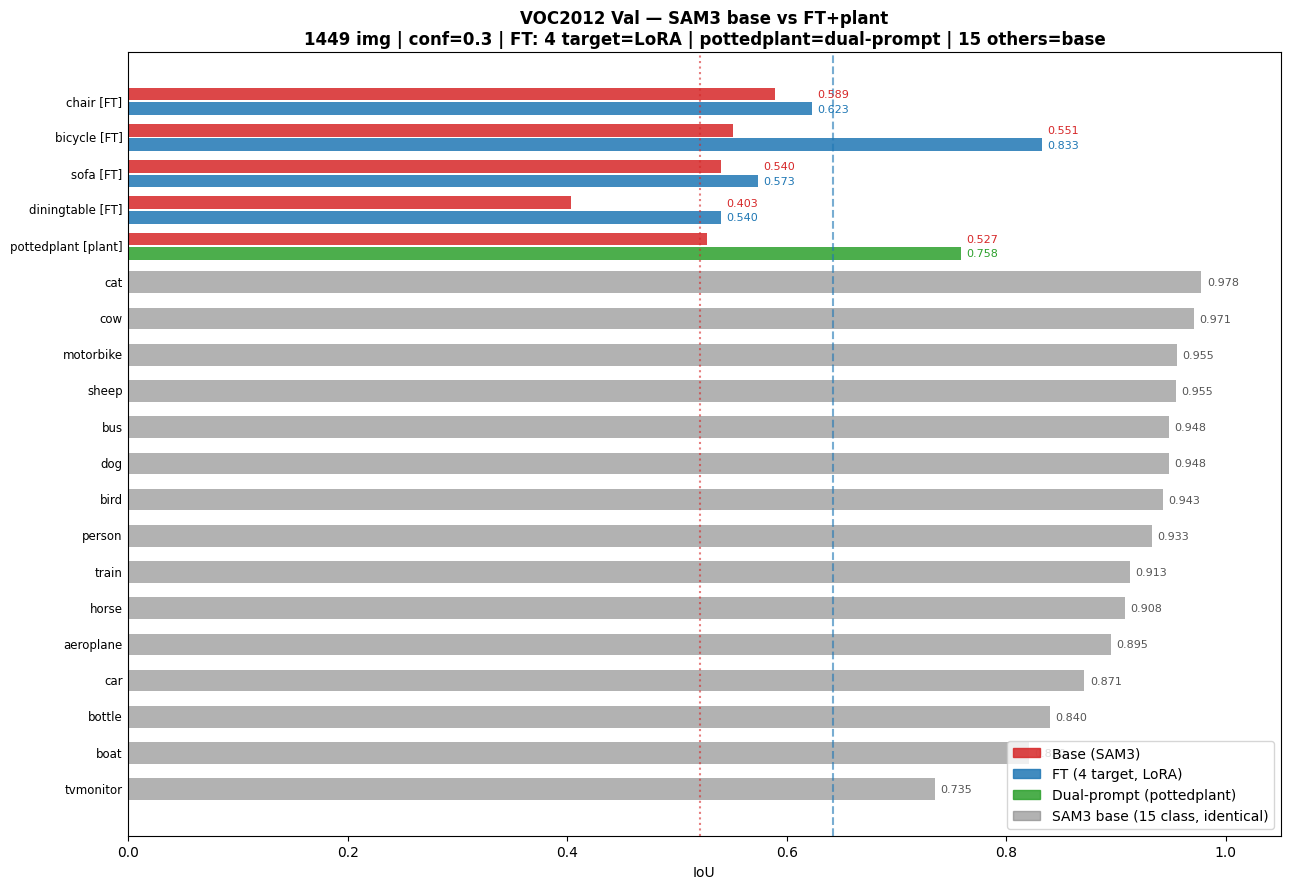

In [8]:
# Bar chart: base vs FT+plant
is_t = [VOC_CLASSES[i] in TARGET_CLASSES for i in range(20)]
is_p = [VOC_CLASSES[i] == 'pottedplant'  for i in range(20)]

def _sort_key(i):
    g = 0 if is_t[i] else (1 if is_p[i] else 2)
    return (g, -iou_base[VOC_IDX[VOC_CLASSES[i]]])

order = sorted(range(20), key=_sort_key)

fig, ax = plt.subplots(figsize=(13, 9))
for rank, oi in enumerate(order):
    cls  = VOC_CLASSES[oi]
    b    = float(iou_base[VOC_IDX[cls]])
    f    = float(iou_ft[VOC_IDX[cls]])
    ypos = 20 - rank - 1

    if is_t[oi]:
        ax.barh(ypos + 0.2, b, 0.35, color='#d62728', alpha=0.85)
        ax.barh(ypos - 0.2, f, 0.35, color='#1f77b4', alpha=0.85)
        xr = max(b, f) + 0.005
        ax.text(xr, ypos + 0.2, f'{b:.3f}', va='center', fontsize=8, color='#d62728')
        ax.text(xr, ypos - 0.2, f'{f:.3f}', va='center', fontsize=8, color='#1f77b4')
        ax.text(-0.005, ypos, f'{cls} [FT]', ha='right', va='center', fontsize=8.5)
    elif is_p[oi]:
        ax.barh(ypos + 0.2, b, 0.35, color='#d62728', alpha=0.85)
        ax.barh(ypos - 0.2, f, 0.35, color='#2ca02c', alpha=0.85)
        xr = max(b, f) + 0.005
        ax.text(xr, ypos + 0.2, f'{b:.3f}', va='center', fontsize=8, color='#d62728')
        ax.text(xr, ypos - 0.2, f'{f:.3f}', va='center', fontsize=8, color='#2ca02c')
        ax.text(-0.005, ypos, f'{cls} [plant]', ha='right', va='center', fontsize=8.5)
    else:
        ax.barh(ypos, b, 0.6, color='#7f7f7f', alpha=0.6)
        ax.text(b + 0.005, ypos, f'{b:.3f}', va='center', fontsize=8, color='#555')
        ax.text(-0.005, ypos, cls, ha='right', va='center', fontsize=8.5)

ax.axvline(mb_t, color='#d62728', ls=':',  alpha=0.6, label=f'base 4-target = {mb_t:.3f}')
ax.axvline(mf_t, color='#1f77b4', ls='--', alpha=0.6, label=f'FT 4-target = {mf_t:.3f}')
ax.set_yticks([])
ax.set_xlim(0, 1.05)
ax.set_xlabel('IoU')
ax.set_title(
    f'VOC2012 Val — SAM3 base vs FT+plant\n'
    f'{len(run_ids)} img | conf={EVAL_CONF} | FT: 4 target=LoRA | pottedplant=dual-prompt | 15 others=base',
    fontsize=12, fontweight='bold',
)
ax.legend(handles=[
    mpatches.Patch(color='#d62728', alpha=0.85, label='Base (SAM3)'),
    mpatches.Patch(color='#1f77b4', alpha=0.85, label='FT (4 target, LoRA)'),
    mpatches.Patch(color='#2ca02c', alpha=0.85, label='Dual-prompt (pottedplant)'),
    mpatches.Patch(color='#7f7f7f', alpha=0.60, label='SAM3 base (15 class, identical)'),
], loc='lower right')
plt.tight_layout()
plt.savefig('/kaggle/working/eval_base_vs_ft_fullval.png', dpi=120, bbox_inches='tight')
plt.show()

if errors:
    print(f'\n[!] {len(errors)} errors (5 dau):')
    for i, m in errors[:5]:
        print(f'  {i}: {m}')